In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nidheesengar/online-news-summary/Online news summary.csv


In [11]:
!pip install networkx rouge-score
import numpy as np
import pandas as pd
import networkx as nx
import nltk
import re
import os
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.metrics.pairwise import cosine_similarity
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/nidheesengar/online-news-summary/Online news summary.csv",
    encoding="latin-1"
)
df.rename(columns={'article': 'text', 'summary': 'headline'}, inplace=True)
print(df.shape)
df.head()

(4498, 2)


,text,headline
0,Ever noticed how plane seats appear to be gett...,Experts question if packed out planes are put...
1,A drunk teenage boy had to be rescued by secur...,Drunk teenage boy climbed into lion enclosure ...
2,Dougie Freedman is on the verge of agreeing a ...,Nottingham Forest are close to extending Dougi...
3,Liverpool target Neto is also wanted by PSG an...,Fiorentina goalkeeper Neto has been linked wit...
4,Bruce Jenner will break his silence in a two-h...,"Tell-all interview with the reality TV star, 6..."


In [5]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/danielwillgeorge/glove6b100dtxt'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/danielwillgeorge/glove6b100dtxt/glove.6B.100d.txt


In [6]:
print(os.listdir('/kaggle/input/datasets/danielwillgeorge/glove6b100dtxt'))
word_embeddings = {}
with open('/kaggle/input/datasets/danielwillgeorge/glove6b100dtxt/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        word_embeddings[word] = vector

print("Total words loaded:", len(word_embeddings))

['glove.6B.100d.txt']
Total words loaded: 400000


In [12]:
stop_words = stopwords.words("english")
print(stop_words[:20])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [13]:
def get_sentence_vector(sentence):
    words = word_tokenize(sentence.lower())
    vectors = []
    for word in words:
        if word in word_embeddings:
            vectors.append(word_embeddings[word])
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

In [14]:
import networkx as nx
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize
def glove_textrank_summary(text, top_n=1):
    sentences = sent_tokenize(str(text))
    if len(sentences) <= top_n:
        return text
    sentence_vectors = []
    
    for s in sentences:
        vec = get_sentence_vector(s)
        
        if np.linalg.norm(vec) == 0:
            vec = np.random.normal(0, 1e-6, size=len(vec))
        
        norm = np.linalg.norm(vec)
        if norm != 0:
            vec = vec / norm
            
        sentence_vectors.append(vec)
    
    sentence_vectors = np.array(sentence_vectors)
    
    sim_mat = cosine_similarity(sentence_vectors)
    
    sim_mat = np.nan_to_num(sim_mat)
    sim_mat[sim_mat < 0] = 0
    np.fill_diagonal(sim_mat, 0)
    
    nx_graph = nx.from_numpy_array(sim_mat)
    
    try:
        scores = nx.pagerank(
            nx_graph,
            alpha=0.85,
            max_iter=1000,
            tol=1e-4
        )
    except nx.PowerIterationFailedConvergence:
        scores = {i: 1/len(sentences) for i in range(len(sentences))}
    
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    top_sentences = sorted([ranked[i][0] for i in range(top_n)])
    
    summary = " ".join([sentences[i] for i in top_sentences])
    
    return summary


In [15]:
text_sample = str(df["text"][0])
print("ORIGINAL:\n", text_sample)
print("\nSUMMARY:\n", glove_textrank_summary(text_sample, top_n=1))


ORIGINAL:
 Ever noticed how plane seats appear to be getting smaller and smaller? With increasing numbers of people taking to the skies, some experts are questioning if having such packed out planes is putting passengers at risk. They say that the shrinking space on aeroplanes is not only uncomfortable - it's putting our health and safety in danger. More than squabbling over the arm rest, shrinking space on planes putting our health and safety in danger? This week, a U.S consumer advisory group set up by the Department of Transportation said at a public hearing that while the government is happy to set standards for animals flying on planes, it doesn't stipulate a minimum amount of space for humans. 'In a world where animals have more rights to space and food than humans,' said Charlie Leocha, consumer representative on the committee.Â 'It is time that the DOT and FAA take a stand for humane treatment of passengers.' But could crowding on planes lead to more serious issues than fightin

In [16]:
df = df.iloc[:50].copy()

df["glove_summary"] = df["text"].apply(
    lambda x: glove_textrank_summary(x, top_n=1)
)

df[["text", "glove_summary"]].head()

,text,glove_summary
0,Ever noticed how plane seats appear to be gett...,But these tests are conducted using planes wit...
1,A drunk teenage boy had to be rescued by secur...,"'Fortunately for him, the lions were asleep an..."
2,Dougie Freedman is on the verge of agreeing a ...,Freedman has stabilised Forest since he replac...
3,Liverpool target Neto is also wanted by PSG an...,A January move for Neto never materialised but...
4,Bruce Jenner will break his silence in a two-h...,Out and about: Jenner was pictured walking bac...


In [62]:
df[["text", "glove_summary"]].to_csv("glove_summary_full.csv", index=False)

In [17]:
df["glove_summary"] = df["text"].apply(
    lambda x: glove_textrank_summary(str(x), top_n=1)
)

In [18]:
for i in range(10):
    print("\nORIGINAL TEXT:\n", df["text"].iloc[i][:500])
    print("\nGLOVE SUMMARY:\n", df["glove_summary"].iloc[i])


ORIGINAL TEXT:
 Ever noticed how plane seats appear to be getting smaller and smaller? With increasing numbers of people taking to the skies, some experts are questioning if having such packed out planes is putting passengers at risk. They say that the shrinking space on aeroplanes is not only uncomfortable - it's putting our health and safety in danger. More than squabbling over the arm rest, shrinking space on planes putting our health and safety in danger? This week, a U.S consumer advisory group set up by t

GLOVE SUMMARY:
 But these tests are conducted using planes with 31 inches between each row of seats, a standard which on some airlines has decreased, reported the Detroit News.

ORIGINAL TEXT:
 A drunk teenage boy had to be rescued by security after jumping into a lions' enclosure at a zoo in western India. Rahul Kumar, 17, clambered over the enclosure fence at theÂ Kamla Nehru Zoological Park in Ahmedabad, and began running towards the animals, shouting he would 'kill them'. 

In [19]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)
r1_p, r1_r, r1_f = [], [], []
r2_p, r2_r, r2_f = [], [], []
rL_p, rL_r, rL_f = [], [], []
df["headline"] = df["headline"].astype(str)
df["glove_summary"] = df["glove_summary"].astype(str)

for i in range(len(df)):
    
    scores = scorer.score(
        df["headline"][i],
        df["glove_summary"][i]
    )
    r1_p.append(scores['rouge1'].precision)
    r1_r.append(scores['rouge1'].recall)
    r1_f.append(scores['rouge1'].fmeasure)
    
    r2_p.append(scores['rouge2'].precision)
    r2_r.append(scores['rouge2'].recall)
    r2_f.append(scores['rouge2'].fmeasure)
    
    rL_p.append(scores['rougeL'].precision)
    rL_r.append(scores['rougeL'].recall)
    rL_f.append(scores['rougeL'].fmeasure)
results = {
    "ROUGE-1": [np.mean(r1_f), np.mean(r1_p), np.mean(r1_r)],
    "ROUGE-2": [np.mean(r2_f), np.mean(r2_p), np.mean(r2_r)],
    "ROUGE-L": [np.mean(rL_f), np.mean(rL_p), np.mean(rL_r)]
}
print("Models\t\tRouge-1\t\tRouge-2\t\tRouge-L")
print("\t\tF\tP\tR\tF\tP\tR\tF\tP\tR")

print("Glove+TR\t"
      f"{results['ROUGE-1'][0]:.3f}\t{results['ROUGE-1'][1]:.3f}\t{results['ROUGE-1'][2]:.3f}\t"
      f"{results['ROUGE-2'][0]:.3f}\t{results['ROUGE-2'][1]:.3f}\t{results['ROUGE-2'][2]:.3f}\t"
      f"{results['ROUGE-L'][0]:.3f}\t{results['ROUGE-L'][1]:.3f}\t{results['ROUGE-L'][2]:.3f}")


Models		Rouge-1		Rouge-2		Rouge-L
		F	P	R	F	P	R	F	P	R
Glove+TR	0.248	0.316	0.223	0.053	0.070	0.049	0.154	0.197	0.140


In [20]:
 !pip install nltk rouge-score scikit-learn networkx

In [21]:
import numpy as np
import pandas as pd
import nltk
import re
import networkx as nx

from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer

nltk.download('punkt')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text

In [24]:
def tfidf_textrank_summary(text, top_n=1):
    sentences = sent_tokenize(text)

    if len(sentences) <= top_n:
        return text

    cleaned_sentences = [clean_text(sent) for sent in sentences]
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(cleaned_sentences)
    similarity_matrix = cosine_similarity(tfidf_matrix)
    nx_graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(nx_graph)
    ranked_sentences = sorted(
        ((scores[i], s) for i, s in enumerate(sentences)),
        reverse=True
    )
    summary = " ".join([ranked_sentences[i][1] for i in range(top_n)])

    return summary


In [25]:
text_sample = str(df["text"][0])
print("ORIGINAL:\n", text_sample)
print("\nSUMMARY:\n", tfidf_textrank_summary(text_sample, top_n=1))

ORIGINAL:
 Ever noticed how plane seats appear to be getting smaller and smaller? With increasing numbers of people taking to the skies, some experts are questioning if having such packed out planes is putting passengers at risk. They say that the shrinking space on aeroplanes is not only uncomfortable - it's putting our health and safety in danger. More than squabbling over the arm rest, shrinking space on planes putting our health and safety in danger? This week, a U.S consumer advisory group set up by the Department of Transportation said at a public hearing that while the government is happy to set standards for animals flying on planes, it doesn't stipulate a minimum amount of space for humans. 'In a world where animals have more rights to space and food than humans,' said Charlie Leocha, consumer representative on the committee.Â 'It is time that the DOT and FAA take a stand for humane treatment of passengers.' But could crowding on planes lead to more serious issues than fightin

In [26]:
df = df.iloc[:50].copy()

df["tfidf_summary"] = df["text"].apply(
    lambda x: tfidf_textrank_summary(x, top_n=1)
)

df[["text", "tfidf_summary"]].head()

,text,tfidf_summary
0,Ever noticed how plane seats appear to be gett...,But these tests are conducted using planes wit...
1,A drunk teenage boy had to be rescued by secur...,"Next level drunk: Intoxicated Rahul Kumar, 17,..."
2,Dougie Freedman is on the verge of agreeing a ...,Dougie Freedman is on the verge of agreeing a ...
3,Liverpool target Neto is also wanted by PSG an...,Liverpool target Neto is also wanted by PSG an...
4,Bruce Jenner will break his silence in a two-h...,Out and about: Jenner was pictured walking bac...


In [61]:
df[["text", "tfidf_summary"]].to_csv("tfidf_summary_full.csv", index=False)

In [27]:
df["tfidf_summary"] = df["text"].apply(
    lambda x: tfidf_textrank_summary(x, top_n=1)
)

In [28]:
for i in range(10):
    print("\nORIGINAL TEXT:\n", df["text"].iloc[i][:500])
    print("\nTFIDF SUMMARY:\n", df["tfidf_summary"].iloc[i])


ORIGINAL TEXT:
 Ever noticed how plane seats appear to be getting smaller and smaller? With increasing numbers of people taking to the skies, some experts are questioning if having such packed out planes is putting passengers at risk. They say that the shrinking space on aeroplanes is not only uncomfortable - it's putting our health and safety in danger. More than squabbling over the arm rest, shrinking space on planes putting our health and safety in danger? This week, a U.S consumer advisory group set up by t

TFIDF SUMMARY:
 But these tests are conducted using planes with 31 inches between each row of seats, a standard which on some airlines has decreased, reported the Detroit News.

ORIGINAL TEXT:
 A drunk teenage boy had to be rescued by security after jumping into a lions' enclosure at a zoo in western India. Rahul Kumar, 17, clambered over the enclosure fence at theÂ Kamla Nehru Zoological Park in Ahmedabad, and began running towards the animals, shouting he would 'kill them'. 

In [29]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)
r1_p, r1_r, r1_f = [], [], []
r2_p, r2_r, r2_f = [], [], []
rL_p, rL_r, rL_f = [], [], []
df["headline"] = df["headline"].astype(str)
df["tfidf_summary"] = df["tfidf_summary"].astype(str)

for i in range(len(df)):
    
    scores = scorer.score(
        df["headline"][i],
        df["tfidf_summary"][i]
    )
    r1_p.append(scores['rouge1'].precision)
    r1_r.append(scores['rouge1'].recall)
    r1_f.append(scores['rouge1'].fmeasure)
    r2_p.append(scores['rouge2'].precision)
    r2_r.append(scores['rouge2'].recall)
    r2_f.append(scores['rouge2'].fmeasure)
    rL_p.append(scores['rougeL'].precision)
    rL_r.append(scores['rougeL'].recall)
    rL_f.append(scores['rougeL'].fmeasure)
results = {
    "ROUGE-1": [np.mean(r1_f), np.mean(r1_p), np.mean(r1_r)],
    "ROUGE-2": [np.mean(r2_f), np.mean(r2_p), np.mean(r2_r)],
    "ROUGE-L": [np.mean(rL_f), np.mean(rL_p), np.mean(rL_r)]
}
print("Models\t\tRouge-1\t\tRouge-2\t\tRouge-L")
print("\t\tF\tP\tR\tF\tP\tR\tF\tP\tR")

print("tfidf+TR\t"
      f"{results['ROUGE-1'][0]:.3f}\t{results['ROUGE-1'][1]:.3f}\t{results['ROUGE-1'][2]:.3f}\t"
      f"{results['ROUGE-2'][0]:.3f}\t{results['ROUGE-2'][1]:.3f}\t{results['ROUGE-2'][2]:.3f}\t"
      f"{results['ROUGE-L'][0]:.3f}\t{results['ROUGE-L'][1]:.3f}\t{results['ROUGE-L'][2]:.3f}")

Models		Rouge-1		Rouge-2		Rouge-L
		F	P	R	F	P	R	F	P	R
tfidf+TR	0.318	0.409	0.280	0.106	0.136	0.093	0.212	0.268	0.187


In [30]:
import numpy as np
import pandas as pd
import re
import nltk
import networkx as nx

from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense

nltk.download('punkt')


2026-03-20 09:53:38.681113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774000418.977545      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774000419.070643      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774000419.830215      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774000419.830259      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774000419.830262      55 computation_placer.cc:177] computation placer alr

True

In [31]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z ]', '', str(text))
    text = text.lower()
    return text
corpus = df["text"].astype(str).apply(clean_text).tolist()


In [33]:
max_words = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(corpus)

sequences = tokenizer.texts_to_sequences(corpus)
padded_sequences = pad_sequences(sequences, maxlen=max_len)


In [34]:
embedding_dim = 100

input_layer = Input(shape=(max_len,))
embedding_layer = Embedding(input_dim=max_words,
                            output_dim=embedding_dim,
                            input_length=max_len)

x = embedding_layer(input_layer)
x = GlobalAveragePooling1D()(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_layer, outputs=output)
model.compile(loss='binary_crossentropy', optimizer='adam')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-03-20 09:54:03.564053: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [35]:
dummy_labels = np.random.randint(0, 2, size=len(padded_sequences))

model.fit(padded_sequences,
          dummy_labels,
          epochs=30,
          batch_size=32)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.6933 
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6879
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6826
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6780
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6727
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6669
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6613
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6559
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6503
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6449
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6382
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6323
Epoch 13/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6252
Epoch 14/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6189
Epoch 15/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6125
Epoch 16/30
2/2 ━━━━━━━━━━━━━━━━━

In [36]:
model.save("nem_embedding_model.keras") 
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [37]:
from tensorflow.keras.models import load_model

model = load_model("nem_embedding_model.keras")


In [38]:
from tensorflow.keras.models import load_model
import pickle
model = load_model("nem_embedding_model.keras")
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
embedding_matrix = model.layers[1].get_weights()[0]

In [39]:
import numpy as np

def get_sentence_vector(sentence):
    
    cleaned = clean_text(sentence)
    seq = tokenizer.texts_to_sequences([cleaned])[0]
    
    if len(seq) == 0:
        return np.zeros(embedding_dim)
    
    vectors = []
    
    for word_index in seq:
        if word_index < max_words:
            vectors.append(embedding_matrix[word_index])
    
    if len(vectors) == 0:
        return np.zeros(embedding_dim)
    
    vec = np.mean(vectors, axis=0)
    norm = np.linalg.norm(vec)
    if norm == 0:
        return np.zeros(embedding_dim)
    
    return vec / norm


In [40]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

def nem_textrank_summary(text, top_n=1):

    sentences = text.split(".")
    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]

    if len(sentences) < 2:
        return text
    sentence_vectors = [get_sentence_vector(s) for s in sentences]
    sim_mat = cosine_similarity(sentence_vectors)
    sim_mat = np.nan_to_num(sim_mat)
    sim_mat[sim_mat < 0] = 0
    np.fill_diagonal(sim_mat, 0)
    nx_graph = nx.from_numpy_array(sim_mat)

    try:
        scores = nx.pagerank(
            nx_graph,
            alpha=0.85,
            max_iter=1000,
            tol=1e-4
        )
    except:
        return sentences[0]
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_sentences = [sentences[i] for i, _ in ranked[:top_n]]

    return " ".join(top_sentences)


In [59]:
df = df.iloc[:50].copy()

df["nem_summary"] = df["text"].apply(
    lambda x: tfidf_textrank_summary(x, top_n=1)
)

df[["text", "nem_summary"]].head()

,text,nem_summary
0,Ever noticed how plane seats appear to be gett...,But these tests are conducted using planes wit...
1,A drunk teenage boy had to be rescued by secur...,"Next level drunk: Intoxicated Rahul Kumar, 17,..."
2,Dougie Freedman is on the verge of agreeing a ...,Dougie Freedman is on the verge of agreeing a ...
3,Liverpool target Neto is also wanted by PSG an...,Liverpool target Neto is also wanted by PSG an...
4,Bruce Jenner will break his silence in a two-h...,Out and about: Jenner was pictured walking bac...


In [60]:
df[["text", "nem_summary"]].to_csv("nem_summary_full.csv", index=False)

In [45]:
df["nem_summary"] = df["text"].apply(
    lambda x: nem_textrank_summary(str(x), top_n=1)
)
for i in range(10):
    print("\nORIGINAL TEXT:\n", df["text"].iloc[i][:500])
    print("\nNEM SUMMARY:\n", df["nem_summary"].iloc[i])
r1_p, r1_r, r1_f = [], [], []
r2_p, r2_r, r2_f = [], [], []
rL_p, rL_r, rL_f = [], [], []
df["nem_summary"] = df["nem_summary"].astype(str)
df["headline"] = df["headline"].astype(str)

for i in range(len(df)):
    
    scores = scorer.score(
        df["headline"][i],
        df["nem_summary"][i]
    )
    r1_p.append(scores['rouge1'].precision)
    r1_r.append(scores['rouge1'].recall)
    r1_f.append(scores['rouge1'].fmeasure)
    r2_p.append(scores['rouge2'].precision)
    r2_r.append(scores['rouge2'].recall)
    r2_f.append(scores['rouge2'].fmeasure)
    rL_p.append(scores['rougeL'].precision)
    rL_r.append(scores['rougeL'].recall)
    rL_f.append(scores['rougeL'].fmeasure)
nem_results = {
    "ROUGE-1": [np.mean(r1_f), np.mean(r1_p), np.mean(r1_r)],
    "ROUGE-2": [np.mean(r2_f), np.mean(r2_p), np.mean(r2_r)],
    "ROUGE-L": [np.mean(rL_f), np.mean(rL_p), np.mean(rL_r)]
}  
print("NEM+TR\t\t"
      f"{nem_results['ROUGE-1'][0]:.3f}\t{nem_results['ROUGE-1'][1]:.3f}\t{nem_results['ROUGE-1'][2]:.3f}\t"
      f"{nem_results['ROUGE-2'][0]:.3f}\t{nem_results['ROUGE-2'][1]:.3f}\t{nem_results['ROUGE-2'][2]:.3f}\t"
      f"{nem_results['ROUGE-L'][0]:.3f}\t{nem_results['ROUGE-L'][1]:.3f}\t{nem_results['ROUGE-L'][2]:.3f}")



ORIGINAL TEXT:
 Ever noticed how plane seats appear to be getting smaller and smaller? With increasing numbers of people taking to the skies, some experts are questioning if having such packed out planes is putting passengers at risk. They say that the shrinking space on aeroplanes is not only uncomfortable - it's putting our health and safety in danger. More than squabbling over the arm rest, shrinking space on planes putting our health and safety in danger? This week, a U.S consumer advisory group set up by t

NEM SUMMARY:
 But these tests are conducted using planes with 31 inches between each row of seats, a standard which on some airlines has decreased, reported the Detroit News

ORIGINAL TEXT:
 A drunk teenage boy had to be rescued by security after jumping into a lions' enclosure at a zoo in western India. Rahul Kumar, 17, clambered over the enclosure fence at theÂ Kamla Nehru Zoological Park in Ahmedabad, and began running towards the animals, shouting he would 'kill them'. Mr 

In [46]:
print(df.columns)

Index(['text', 'headline', 'glove_summary', 'tfidf_summary', 'nem_summary'], dtype='object')


In [48]:
df["glove_summary"]
df["tfidf_summary"]
df["nem_summary"]
df["headline"]  

0     Experts question if  packed out planes are put...
1     Drunk teenage boy climbed into lion enclosure ...
2     Nottingham Forest are close to extending Dougi...
3     Fiorentina goalkeeper Neto has been linked wit...
4     Tell-all interview with the reality TV star, 6...
5     Giant pig fell into the swimming pool at his h...
6     Figures show that while millions still tune in...
7     Show will return with a one-hour special, foll...
8     Reanne Evans faced Ken Doherty in World Champi...
9     Gang have been jailed for a total of 31 years ...
10    Mohammed Ali Malek, 27, has been charged with ...
11    Lippert, 42, suffered deep gashes to his hand ...
12    Alastair Cook completed his century on the sec...
13    U.S. hostage Warren Weinstein is believed to h...
14    Sofia Davila, 21, nicknamed the 'Black Widow o...
15    Australian Fashion Report revealed the Austral...
16    Arsenal take on Stoke City in Barclays Under 2...
17    Prasanna Arulchelvam leapt into van as it 

In [52]:
from rouge_score import rouge_scorer
import numpy as np

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)
def compute_rouge_scores(reference_col, summary_col):
    
    r1_f, r2_f, rL_f = [], [], []
    r1_p, r2_p, rL_p = [], [], []
    r1_r, r2_r, rL_r = [], [], []
    
    for ref, pred in zip(df[reference_col], df[summary_col]):
        
        ref = str(ref)
        pred = str(pred)
        
        scores = scorer.score(ref, pred)
        
        r1_f.append(scores['rouge1'].fmeasure)
        r1_p.append(scores['rouge1'].precision)
        r1_r.append(scores['rouge1'].recall)
        
        r2_f.append(scores['rouge2'].fmeasure)
        r2_p.append(scores['rouge2'].precision)
        r2_r.append(scores['rouge2'].recall)
        
        rL_f.append(scores['rougeL'].fmeasure)
        rL_p.append(scores['rougeL'].precision)
        rL_r.append(scores['rougeL'].recall)
    
    return {
        "R1_F": np.mean(r1_f),
        "R1_P": np.mean(r1_p),
        "R1_R": np.mean(r1_r),
        "R2_F": np.mean(r2_f),
        "R2_P": np.mean(r2_p),
        "R2_R": np.mean(r2_r),
        "RL_F": np.mean(rL_f),
        "RL_P": np.mean(rL_p),
        "RL_R": np.mean(rL_r),
    }
glove_scores = compute_rouge_scores("headline", "glove_summary")
tfidf_scores = compute_rouge_scores("headline", "tfidf_summary")
nem_scores   = compute_rouge_scores("headline", "nem_summary")


In [55]:
print("Model\t\tR1-F\tR2-F\tRL-F")

print(f"TFIDF+TR\t{glove_scores['R1_F']:.3f}\t{glove_scores['R2_F']:.3f}\t{glove_scores['RL_F']:.3f}")

print(f"GloVe+TR\t{tfidf_scores['R1_F']:.3f}\t{tfidf_scores['R2_F']:.3f}\t{tfidf_scores['RL_F']:.3f}")

print(f"NEM+TR\t\t{nem_scores['R1_F']:.3f}\t{nem_scores['R2_F']:.3f}\t{nem_scores['RL_F']:.3f}")


Model		R1-F	R2-F	RL-F
TFIDF+TR	0.248	0.053	0.154
GloVe+TR	0.318	0.106	0.212
NEM+TR		0.220	0.049	0.149


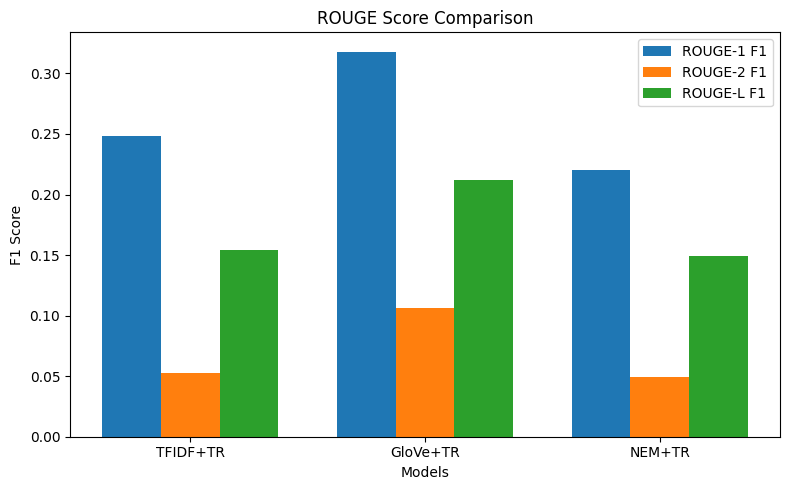

In [56]:
import matplotlib.pyplot as plt
import numpy as np
models = ["TFIDF+TR", "GloVe+TR", "NEM+TR"]
r1 = [0.248, 0.318, 0.220]
r2 = [0.053, 0.106, 0.049]
rl = [0.154, 0.212, 0.149]

x = np.arange(len(models))
width = 0.25
plt.figure(figsize=(8,5))

plt.bar(x - width, r1, width, label="ROUGE-1 F1")
plt.bar(x, r2, width, label="ROUGE-2 F1")
plt.bar(x + width, rl, width, label="ROUGE-L F1")

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("ROUGE Score Comparison")
plt.legend()

plt.tight_layout()
plt.show()

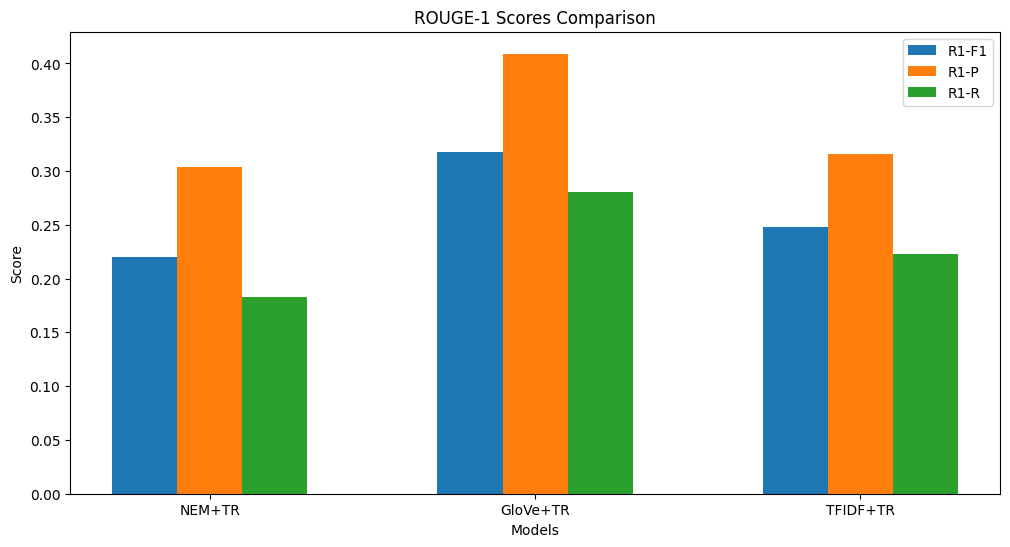

In [58]:
import matplotlib.pyplot as plt
import numpy as np

models = ["NEM+TR","GloVe+TR","TFIDF+TR"]

r1_f = [0.220, 0.318, 0.248]
r1_p = [0.304, 0.409, 0.316]
r1_r = [0.183, 0.280, 0.223]

r2_f = [0.049, 0.106, 0.053]
r2_p = [0.068, 0.136, 0.070]
r2_r = [0.041, 0.093, 0.049]

rl_f = [0.149, 0.212, 0.154]
rl_p = [0.207, 0.268, 0.197]
rl_r = [0.125, 0.187, 0.140]

x = np.arange(len(models))
width = 0.2
plt.figure(figsize=(12,6))

plt.bar(x - width, r1_f, width, label="R1-F1")
plt.bar(x, r1_p, width, label="R1-P")
plt.bar(x + width, r1_r, width, label="R1-R")

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("ROUGE-1 Scores Comparison")
plt.legend()
plt.show()